In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
DATA_DIR = Path("C:/Project_Folder_ML26/Notebook/data/raw")
PROCESSED_DIR = Path("C:/Project_Folder_ML26/Notebook/data/processed")
REPORTS_DIR = Path("C:/Project_Folder_ML26/Notebook/reports")
FIGURES_DIR = Path("C:/Project_Folder_ML26/Notebook/figures")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
for file in DATA_DIR.glob("*.csv"):
    print(file.name)

olist_customers_dataset.csv
Olist_Data_Dictionary.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [6]:
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR /"product_category_name_translation.csv")

In [9]:
tables = {
    "orders": orders,
    "customers": customers,
    "reviews": reviews,
    "payments": payments,
    "order_items": order_items,
    "products": products,
    "category_translation": category_translation
}
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

orders: 99441 rows, 8 columns
customers: 99441 rows, 5 columns
reviews: 99224 rows, 7 columns
payments: 103886 rows, 5 columns
order_items: 112650 rows, 7 columns
products: 32951 rows, 9 columns
category_translation: 71 rows, 2 columns


In [10]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [11]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [12]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [13]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [16]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col],errors="coerce")

In [17]:
orders[date_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       99441 non-null  datetime64[us]
 1   order_approved_at              99281 non-null  datetime64[us]
 2   order_delivered_carrier_date   97658 non-null  datetime64[us]
 3   order_delivered_customer_date  96476 non-null  datetime64[us]
 4   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5)
memory usage: 3.8 MB


In [18]:
orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.month
orders["order_day"] = orders["order_purchase_timestamp"].dt.day
orders["order_day_of_week"] = orders["order_purchase_timestamp"].dt.dayofweek
orders["order_hour"] = orders["order_purchase_timestamp"].dt.hour

In [19]:
orders[[
"order_purchase_timestamp",
"order_year",
"order_month",
"order_day",
"order_day_of_week",
"order_hour"
]].head()

,order_purchase_timestamp,order_year,order_month,order_day,order_day_of_week,order_hour
0,2017-10-02 10:56:33,2017,10,2,0,10
1,2018-07-24 20:41:37,2018,7,24,1,20
2,2018-08-08 08:38:49,2018,8,8,2,8
3,2017-11-18 19:28:06,2017,11,18,5,19
4,2018-02-13 21:18:39,2018,2,13,1,21


In [20]:
orders["delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days
orders["estimated_delivery_days"] = (orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]).dt.days
orders["delivery_delay_days"] = (orders ["order_delivered_customer_date"] - orders["order_estimated_delivery_date"] ).dt.days

In [21]:
orders["is_late_delivery"] = np.where( orders["delivery_delay_days"] > 0,1,0)

In [22]:
orders[["order_id",
"order_status",
"delivery_days",
"estimated_delivery_days",
"delivery_delay_days",
"is_late_delivery"]].head()

,order_id,order_status,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,8.0,15,-8.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,13.0,19,-6.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,9.0,26,-18.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,13.0,26,-13.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2.0,12,-10.0,0


In [24]:
orders["is_late_delivery"].value_counts()

is_late_delivery
0    92906
1     6535
Name: count, dtype: int64

In [25]:
orders["is_late_delivery"].value_counts(normalize=True)*100

is_late_delivery
0    93.428264
1     6.571736
Name: proportion, dtype: float64

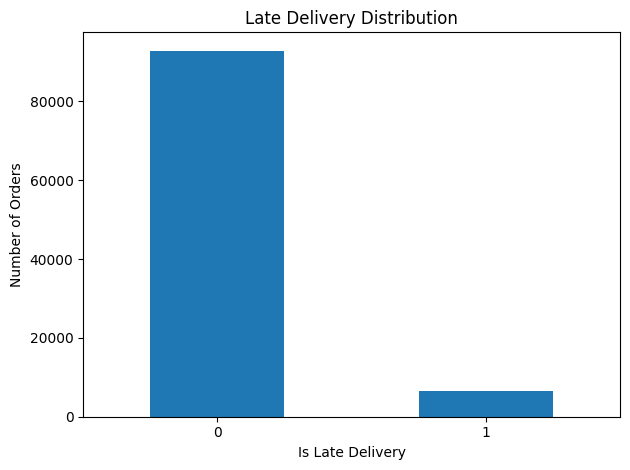

In [26]:
orders["is_late_delivery"].value_counts().plot(kind="bar") 
plt.title("Late Delivery Distribution") 
plt.xlabel("Is Late Delivery")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_late_delivery_distribution.png")
plt.show()

In [27]:
payment_features = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    max_payment_installments=("payment_installments", "max"),
    payment_types_count=("payment_type", "nunique")).reset_index()

In [28]:
payment_features.head()

,order_id,total_payment_value,max_payment_installments,payment_types_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [30]:
dominant_payment_type = payments.groupby("order_id")["payment_type"].agg(
lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).reset_index()

dominant_payment_type = dominant_payment_type.rename(
     columns={"payment_type": "dominant_payment_type"})

payment_features = payment_features.merge(
dominant_payment_type,
on="order_id",
how="left"
)

In [33]:
item_features = order_items.groupby("order_id").agg(
    total_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    unique_products=("product_id", "nunique"),
    unique_sellers=("seller_id", "nunique")).reset_index()

In [35]:
item_features.head()

,order_id,total_items,total_price,total_freight,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1


In [41]:
items_products = order_items.merge(products, on="product_id", how="left")

In [42]:
items_products = items_products.merge(category_translation, on="product_category_name", how="left")

In [44]:
items_products[[
    "order_id",
    "product_id",
    "product_category_name",
    "product_category_name_english"]].head()

,order_id,product_id,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,garden_tools


In [45]:
order_category= items_products.groupby("order_id").agg(
    main_product_category=("product_category_name_english",
     lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
).reset_index()

In [46]:
order_category.head()

,order_id,main_product_category
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools


In [48]:
review_features=reviews.groupby("order_id").agg(
    review_score=("review_score", "mean"),
    review_comment_count=("review_comment_message", lambda x:x.notnull().sum()), 
    has_review_comment=("review_comment_message", lambda x: int(x.notnull().any())) ).reset_index()

In [49]:
review_features.head()

,order_id,review_score,review_comment_count,has_review_comment
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,0,0
2,000229ec398224ef6ca0657da4fc703e,5.0,1,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1,1


In [50]:
abt = orders.merge(
    customers,
    on="customer_id",
    how="left")

abt = abt.merge(
    review_features,
    on="order_id",
    how="left")

abt = abt.merge(
    payment_features,
    on="order_id",
    how="left")


abt = abt.merge(
    item_features,
    on="order_id",
    how="left")

abt = abt.merge(
    order_category,
    on="order_id",
    how="left")

In [51]:
abt.shape

(99441, 34)

In [52]:
abt["is_low_review"] = np.where(abt["review_score"]<=2,1,0)

In [53]:
abt["is_low_review"].value_counts()

is_low_review
0    84992
1    14449
Name: count, dtype: int64

In [54]:
abt["is_low_review"].value_counts(normalize=True)*100

is_low_review
0    85.469776
1    14.530224
Name: proportion, dtype: float64

In [55]:
selected_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "order_status",
    "order_year",
    "order_month",
    "order_day",
    "order_day_of_week",
    "order_hour",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "review_score",
    "is_low_review",
    "review_comment_count",
    "has_review_comment",
    "total_payment_value",
    "max_payment_installments",
    "payment_types_count",
    "dominant_payment_type",
    "total_items",
    "total_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "main_product_category"]
abt = abt[selected_columns]

In [56]:
abt.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,is_low_review,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,10,8.0,15,-8.0,0,4.0,0,1.0,1.0,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,20,13.0,19,-6.0,0,4.0,0,1.0,1.0,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,8,9.0,26,-18.0,0,5.0,0,0.0,0.0,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,19,13.0,26,-13.0,0,5.0,0,1.0,1.0,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,21,2.0,12,-10.0,0,5.0,0,0.0,0.0,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [57]:
abt.shape

(99441, 29)

In [60]:
abt.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  99441 non-null  str    
 1   customer_id               99441 non-null  str    
 2   customer_unique_id        99441 non-null  str    
 3   customer_city             99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   order_status              99441 non-null  str    
 6   order_year                99441 non-null  int32  
 7   order_month               99441 non-null  int32  
 8   order_day                 99441 non-null  int32  
 9   order_day_of_week         99441 non-null  int32  
 10  order_hour                99441 non-null  int32  
 11  delivery_days             96476 non-null  float64
 12  estimated_delivery_days   99441 non-null  int64  
 13  delivery_delay_days       96476 non-null  float64
 14  is_late_delivery 

In [61]:
abt.isnull().sum().sort_values(ascending=False)

delivery_days               2965
delivery_delay_days         2965
main_product_category       2185
total_freight                775
unique_sellers               775
unique_products              775
total_price                  775
total_items                  775
review_score                 768
has_review_comment           768
review_comment_count         768
total_payment_value            1
max_payment_installments       1
payment_types_count            1
dominant_payment_type          1
order_day_of_week              0
order_day                      0
estimated_delivery_days        0
order_hour                     0
order_status                   0
customer_state                 0
order_id                       0
customer_city                  0
customer_unique_id             0
customer_id                    0
order_year                     0
order_month                    0
is_late_delivery               0
is_low_review                  0
dtype: int64

In [62]:
abt["order_id"].duplicated().sum()

np.int64(0)

In [63]:
abt_summary = pd.DataFrame({
    "column": abt.columns,
    "data_type": abt.dtypes.astype(str).values,
    "missing_count": abt.isnull().sum().values,
    "missing_percent": (abt.isnull().sum().values / len(abt)) * 100,
    "unique_values": [abt[col].nunique() for col in abt.columns]})

In [64]:
abt_summary

,column,data_type,missing_count,missing_percent,unique_values
0,order_id,str,0,0.000000,99441
1,customer_id,str,0,0.000000,99441
2,customer_unique_id,str,0,0.000000,96096
3,customer_city,str,0,0.000000,4119
4,customer_state,str,0,0.000000,27
5,order_status,str,0,0.000000,8
6,order_year,int32,0,0.000000,3
7,order_month,int32,0,0.000000,12
8,order_day,int32,0,0.000000,31
9,order_day_of_week,int32,0,0.000000,7


In [65]:
abt_summary.to_csv(REPORTS_DIR / "lab02_abt_summary.csv",index=False)

<function matplotlib.pyplot.show(close=None, block=None)>

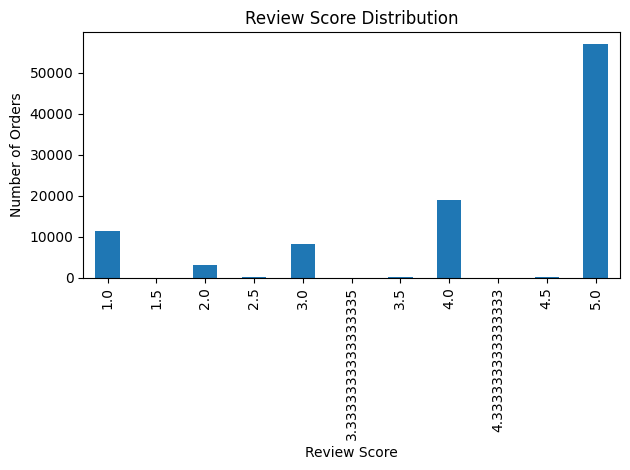

In [66]:
#Review Score Distribution
abt["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_review_score_distribution.png")
plt.show

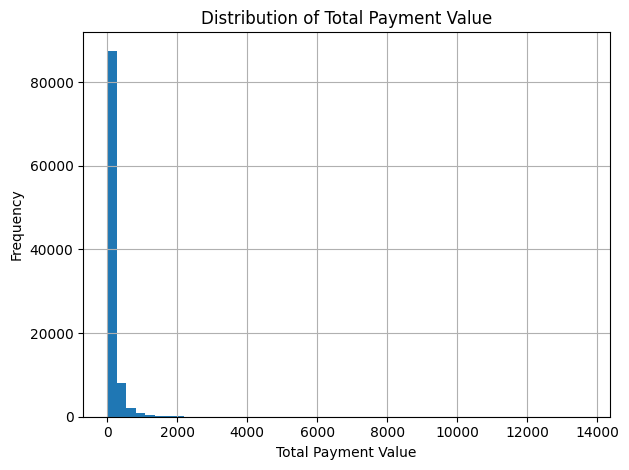

In [68]:
#Payment Value Distribution
abt["total_payment_value"].hist(bins=50)
plt.title("Distribution of Total Payment Value")
plt.xlabel("Total Payment Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_payment_value_distribution.png")
plt.show()

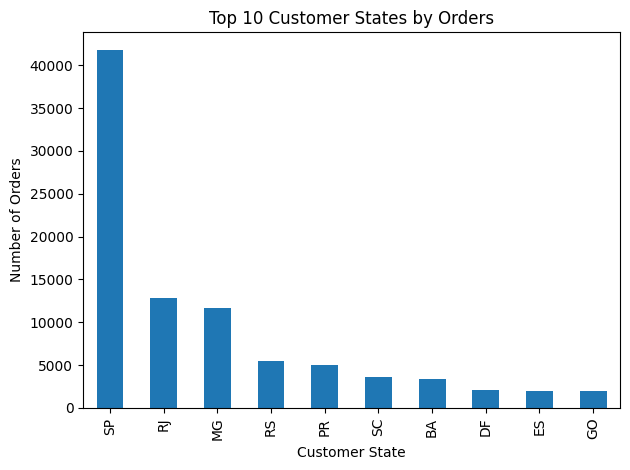

In [70]:
#Top Customer States
abt["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Customer States by Orders")
plt.xlabel("Customer State")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_top_customer_states.png")
plt.show()

In [71]:
abt.to_csv(PROCESSED_DIR / "olist_orders_abt.csv",index=False)

In [72]:
(PROCESSED_DIR / "olist_orders_abt.csv").exists()

True